In [2]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
from pathlib import Path
import pandas as pd

In [6]:
data_folder = Path("../data")
csv_files = data_folder.glob("*.csv")
# [print(file) for file in csv_files]
datas = [pd.read_csv(file) for file in csv_files]

In [7]:
data = datas[0]

,time,G(i),H_sun,T2m,WS10m,Int
0,20050101:0009,0.0,0.0,4.75,1.93,0.0
1,20050101:0109,0.0,0.0,4.63,1.93,0.0
2,20050101:0209,0.0,0.0,4.44,2.00,0.0
3,20050101:0309,0.0,0.0,4.27,1.86,0.0
4,20050101:0409,0.0,0.0,4.03,1.66,0.0
...,...,...,...,...,...,...
95,20050104:2309,0.0,0.0,6.69,2.97,0.0
96,20050105:0009,0.0,0.0,6.91,2.41,0.0
97,20050105:0109,0.0,0.0,6.98,2.28,0.0
98,20050105:0209,0.0,0.0,6.83,2.07,0.0


In [11]:
data.head(100)

,time,G(i),H_sun,T2m,WS10m,Int,datetime,timedelta,hours_since_start
0,20050101:0009,0.0,0.0,4.75,1.93,0.0,2005-01-01 00:09:00,0 days 00:00:00,0.0
1,20050101:0109,0.0,0.0,4.63,1.93,0.0,2005-01-01 01:09:00,0 days 01:00:00,1.0
2,20050101:0209,0.0,0.0,4.44,2.00,0.0,2005-01-01 02:09:00,0 days 02:00:00,2.0
3,20050101:0309,0.0,0.0,4.27,1.86,0.0,2005-01-01 03:09:00,0 days 03:00:00,3.0
4,20050101:0409,0.0,0.0,4.03,1.66,0.0,2005-01-01 04:09:00,0 days 04:00:00,4.0
...,...,...,...,...,...,...,...,...,...
95,20050104:2309,0.0,0.0,6.69,2.97,0.0,2005-01-04 23:09:00,3 days 23:00:00,95.0
96,20050105:0009,0.0,0.0,6.91,2.41,0.0,2005-01-05 00:09:00,4 days 00:00:00,96.0
97,20050105:0109,0.0,0.0,6.98,2.28,0.0,2005-01-05 01:09:00,4 days 01:00:00,97.0
98,20050105:0209,0.0,0.0,6.83,2.07,0.0,2005-01-05 02:09:00,4 days 02:00:00,98.0


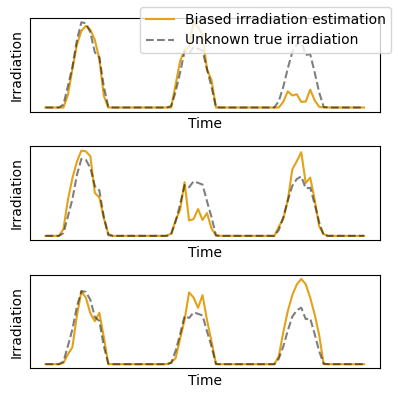

In [50]:
import matplotlib.pyplot as plt
import numpy as np

num_values = 72

filtered_data = data[data['datetime'].dt.hour == 1].reset_index()
desired_positions = [15, 56, 43]
start_indices = filtered_data.iloc[desired_positions]['index'].tolist()

fig, axs = plt.subplots(3, 1, figsize=(4, 4))

times = []
irradiations = []
for idx in start_indices:
    datetimes = pd.to_datetime(data['time'].iloc[idx:idx + num_values], format='%Y%m%d:%H%M')
    timedelta_series = datetimes - datetimes.iloc[0]
    time = timedelta_series / pd.Timedelta(hours=1)
    irradiation = data['G(i)'].iloc[idx:idx + num_values].values
    
    times.append(time)
    irradiations.append(irradiation)

# Compute the time-point-wise mean of irradiations
mean_irradiation = np.mean(irradiations, axis=0)

for ax, time, irradiation in zip(axs, times, irradiations):
    ax.plot(time, irradiation, color='#E2A219', label='Biased irradiation estimation')
    ax.plot(time, mean_irradiation, color='black', alpha = 0.5, linestyle='--', label='Unknown true irradiation')
    ax.set_ylabel("Irradiation")
    ax.set_xlabel("Time")
    ax.set_xticks([])
    ax.set_yticks([])
# Display legend
handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right')

plt.tight_layout()
plt.show()

fig.savefig("irradiation_example.svg", format="svg")